In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

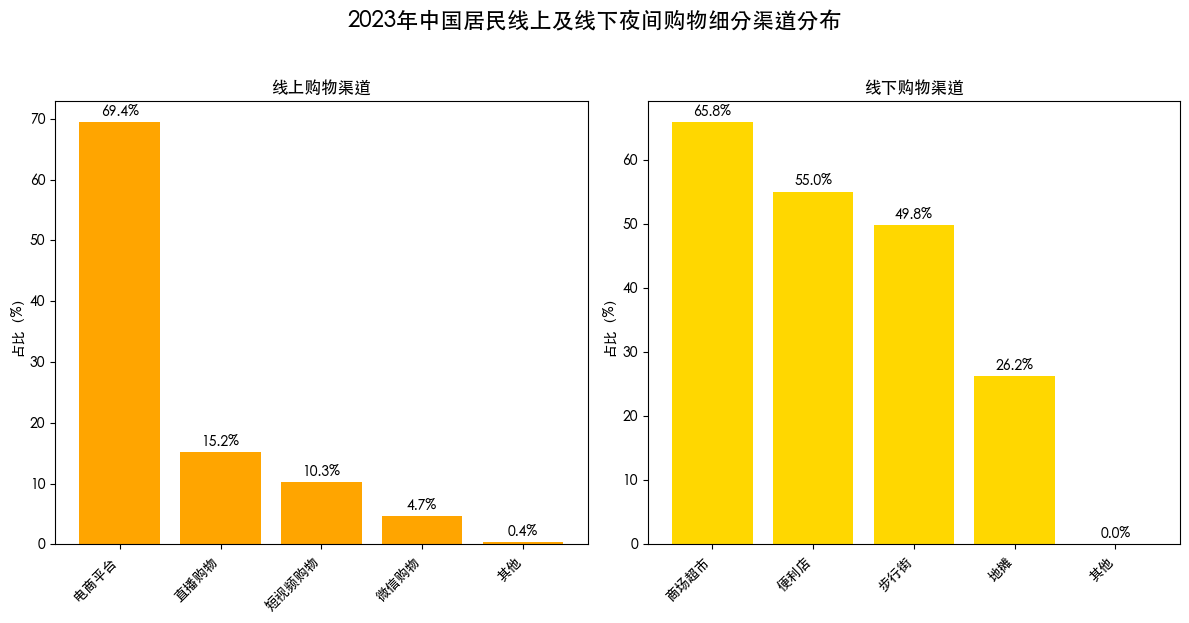

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
online_channels = ["电商平台", "直播购物", "短视频购物", "微信购物", "其他"]
online_percentages = [69.4, 15.2, 10.3, 4.7, 0.4]

offline_channels = ["商场超市", "便利店", "步行街", "地摊", "其他"]
offline_percentages = [65.8, 55.0, 49.8, 26.2, 0.0]

# 设置画布和子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 绘制线上购物渠道柱状图
x1 = np.arange(len(online_channels))
bars1 = ax1.bar(x1, online_percentages, color='orange')
ax1.set_title('线上购物渠道')
ax1.set_ylabel('占比（%）')
ax1.set_xticks(x1)
ax1.set_xticklabels(online_channels, rotation=45, ha='right')

# 添加线上购物渠道数值标注
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height}%', ha='center', va='bottom')

# 绘制线下购物渠道柱状图
x2 = np.arange(len(offline_channels))
bars2 = ax2.bar(x2, offline_percentages, color='gold')
ax2.set_title('线下购物渠道')
ax2.set_ylabel('占比（%）')
ax2.set_xticks(x2)
ax2.set_xticklabels(offline_channels, rotation=45, ha='right')

# 添加线下购物渠道数值标注
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height}%', ha='center', va='bottom')

plt.suptitle('2023年中国居民线上及线下夜间购物细分渠道分布', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

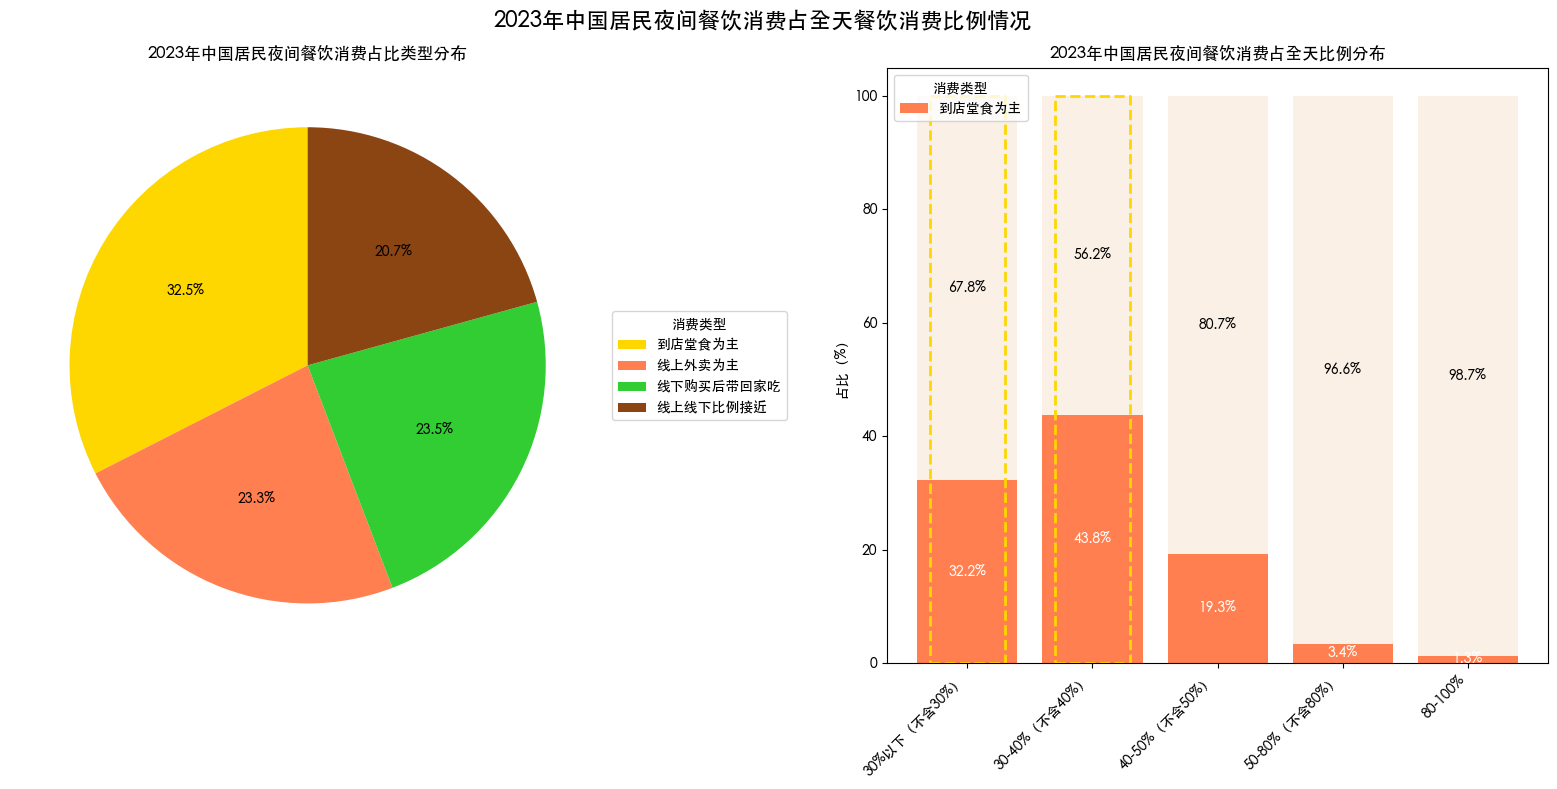

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------- 左侧饼图数据 ---------------------
pie_labels = ["到店堂食为主", "线上外卖为主", "线下购买后带回家吃", "线上线下比例接近"]
pie_sizes = [32.5, 23.3, 23.5, 20.7]
pie_colors = ["#FFD700", "#FF7F50", "#32CD32", "#8B4513"]

# --------------------- 右侧分组柱状图数据 ---------------------
bar_categories = ["30%以下（不含30%）", "30-40%（不含40%）", "40-50%（不含50%）", "50-80%（不含80%）", "80-100%"]
bar_values = [
    [32.2, 67.8],  # 第一组：橙色部分、浅色部分
    [43.8, 56.2], 
    [19.3, 80.7], 
    [3.4, 96.6], 
    [1.3, 98.7]
]
bar_colors = ["#FF7F50", "#FAF0E6"]  # 橙色、浅米色

# 创建画布，一行两列布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --------------------- 绘制左侧饼图 ---------------------
wedges, texts, autotexts = ax1.pie(pie_sizes, colors=pie_colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('2023年中国居民夜间餐饮消费占比类型分布')
# 调整图例
ax1.legend(wedges, pie_labels, title="消费类型", loc="center left", bbox_to_anchor=(1, 0.5))
# 调整标注文字颜色
for autotext in autotexts:
    autotext.set_color('white' if autotext.get_position()[1] > 0.5 else 'black')

# --------------------- 绘制右侧分组柱状图 ---------------------
x = np.arange(len(bar_categories))
bottom = np.zeros(len(bar_categories))
for i in range(2):
    ax2.bar(x, [val[i] for val in bar_values], bottom=bottom, color=bar_colors[i], label=pie_labels[i] if i==0 else '')
    bottom += [val[i] for val in bar_values]

ax2.set_title('2023年中国居民夜间餐饮消费占全天比例分布')
ax2.set_ylabel('占比（%）')
ax2.set_xticks(x)
ax2.set_xticklabels(bar_categories, rotation=45, ha='right')
ax2.legend(title="消费类型", loc="upper left")

# 添加分组柱状图数值标注
for i, (val1, val2) in enumerate(bar_values):
    ax2.text(i, val1/2, f'{val1}%', ha='center', va='center', color='white')
    ax2.text(i, val1 + val2/2, f'{val2}%', ha='center', va='center', color='black')

# 模拟黄色虚线框（前两组）
ax2.plot([x[0]-0.3, x[0]+0.3, x[0]+0.3, x[0]-0.3, x[0]-0.3], 
         [0, 0, 100, 100, 0], 
         linestyle='--', color='gold', linewidth=2)
ax2.plot([x[1]-0.3, x[1]+0.3, x[1]+0.3, x[1]-0.3, x[1]-0.3], 
         [0, 0, 100, 100, 0], 
         linestyle='--', color='gold', linewidth=2)

plt.suptitle('2023年中国居民夜间餐饮消费占全天餐饮消费比例情况', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

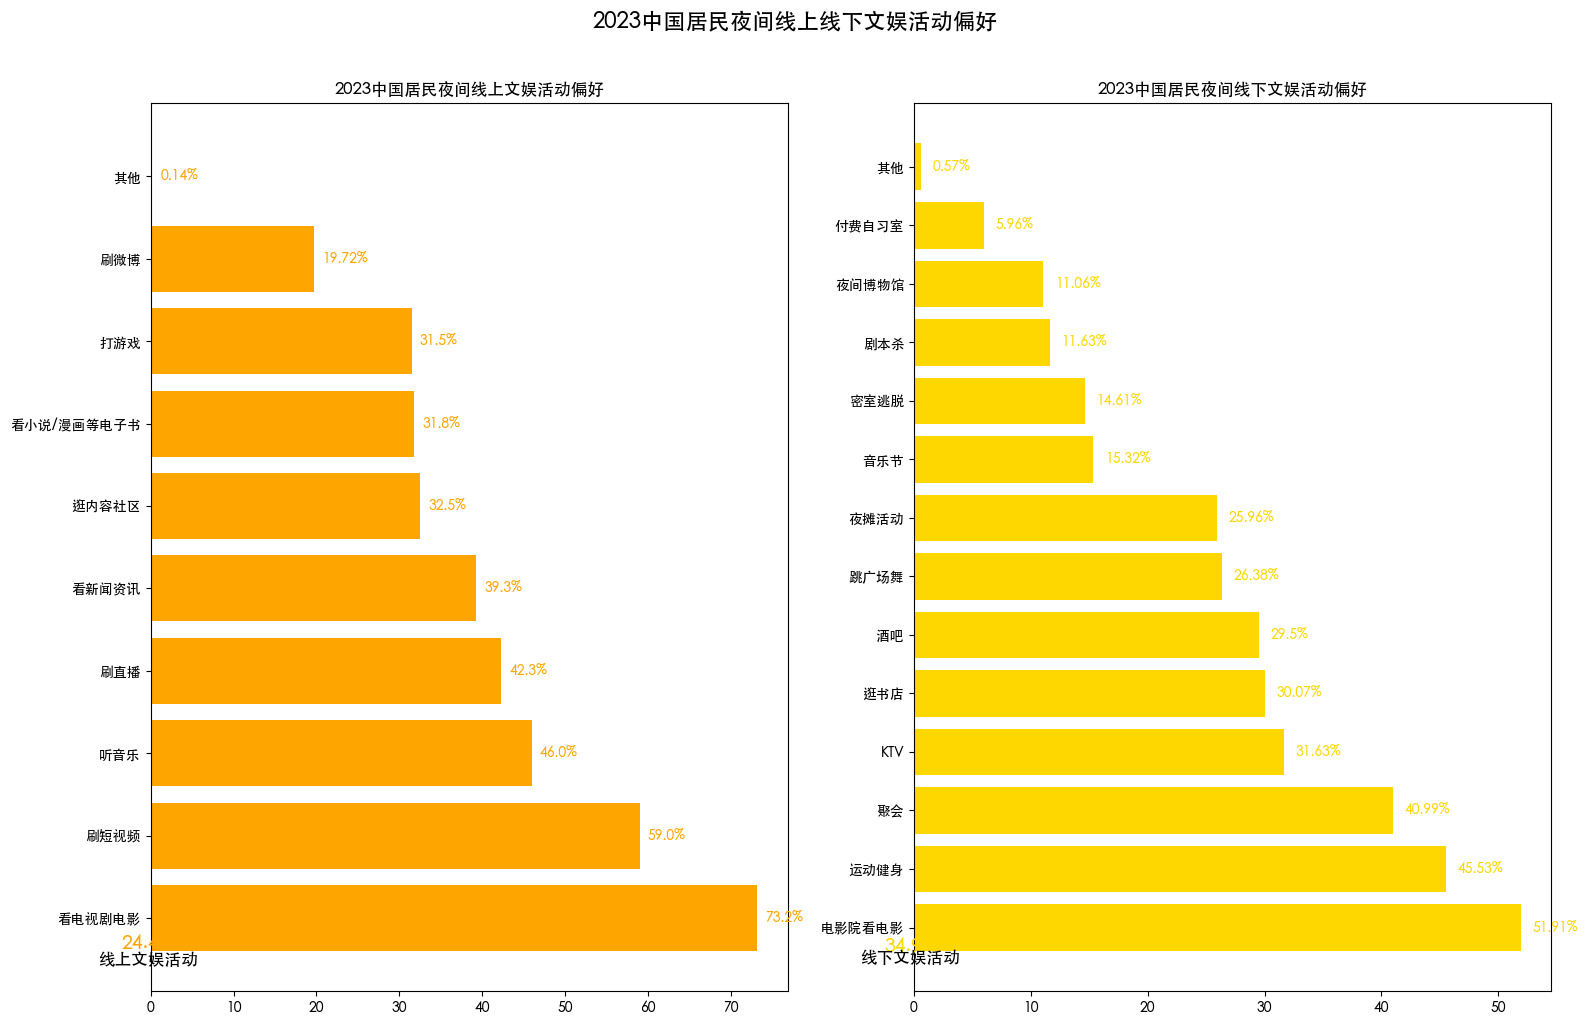

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备（线上、线下文娱活动及占比）
online_data = {
    "看电视剧电影": 73.2, "刷短视频": 59.0, "听音乐": 46.0, 
    "刷直播": 42.3, "看新闻资讯": 39.3, "逛内容社区": 32.5, 
    "看小说/漫画等电子书": 31.8, "打游戏": 31.5, "刷微博": 19.72, "其他": 0.14
}
offline_data = {
    "电影院看电影": 51.91, "运动健身": 45.53, "聚会": 40.99, 
    "KTV": 31.63, "逛书店": 30.07, "酒吧": 29.50, "跳广场舞": 26.38, 
    "夜摊活动": 25.96, "音乐节": 15.32, "密室逃脱": 14.61, "剧本杀": 11.63, 
    "夜间博物馆": 11.06, "付费自习室": 5.96, "其他": 0.57
}
# 环形占比
online_ring = 24.4
offline_ring = 34.9

# 创建画布，一行两列布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

# --------------------- 绘制左侧线上文娱横向柱状图 ---------------------
x_online = list(online_data.values())
y_online = list(online_data.keys())
ax1.barh(y_online, x_online, color='orange')
ax1.set_title('2023中国居民夜间线上文娱活动偏好', fontsize=12)
# 添加数值标注
for i, val in enumerate(x_online):
    ax1.text(val + 1, i, f'{val}%', ha='left', va='center', color='orange')
# 绘制环形占比
ax1_ring = plt.Circle((-0.3, -0.3), 0.2, color='white')
ax1.add_artist(ax1_ring)
ax1.text(-0.3, -0.3, f'{online_ring}%', ha='center', va='center', fontsize=14, color='orange')
ax1.text(-0.3, -0.5, '线上文娱活动', ha='center', va='center', fontsize=12)

# --------------------- 绘制右侧线下文娱横向柱状图 ---------------------
x_offline = list(offline_data.values())
y_offline = list(offline_data.keys())
ax2.barh(y_offline, x_offline, color='gold')
ax2.set_title('2023中国居民夜间线下文娱活动偏好', fontsize=12)
# 添加数值标注
for i, val in enumerate(x_offline):
    ax2.text(val + 1, i, f'{val}%', ha='left', va='center', color='gold')
# 绘制环形占比
ax2_ring = plt.Circle((-0.3, -0.3), 0.2, color='white')
ax2.add_artist(ax2_ring)
ax2.text(-0.3, -0.3, f'{offline_ring}%', ha='center', va='center', fontsize=14, color='gold')
ax2.text(-0.3, -0.5, '线下文娱活动', ha='center', va='center', fontsize=12)

# 调整布局
plt.suptitle('2023中国居民夜间线上线下文娱活动偏好', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()